# Does the Rainforest Split Into Classes On Its Own?

**Unsupervised classification of Tawau Hills Park, Sabah, Malaysian Borneo**

The [supervised notebook](07_multisensor_classification.ipynb) asked how well a classifier
reproduces a set of labels we gave it. Six classes went in — natural forest, oil palm,
mangrove, water, built-up, grassland — and the best stack agreed with them on about three
quarters of the points. Those labels came from two global maps, and global maps have a
coarse idea of what a rainforest is: everything under a closed canopy that is not a
plantation is "tree cover".

This notebook asks the opposite question. Given a two-sensor feature stack and **no labels
at all**, how many groups does the imagery itself fall into, and do any of them live
*inside* what the reference map calls natural forest? Tawau Hills Park is a good place to
ask: it climbs from about 100 m to the 1310 m of Gunung Magdalena, and that gradient is
supposed to carry lowland dipterocarp forest into hill dipterocarp and then lower montane
forest. If those are distinguishable from space, a clusterer that has never been told they
exist should find them.

We ask for **twelve clusters** — twice the six classes of the supervised run, so that the
obvious covers (water, built-up, plantation) can take one each and still leave room for the
forest to split. Three algorithms are compared, because they disagree in instructive ways.

```{note}
This notebook takes roughly half an hour. Clustering an image is not free: every request
that touches the result rebuilds the composites underneath it, so each map below is a
computation of several minutes.
```

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality, LandCoverClassifier

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


## 2. The study area

The park itself, plus an 8 km buffer. The buffer is what makes the question answerable: it
brings in the oil palm, the towns and the rivers that surround the park, so the clusterer
has to spend some of its twelve groups on them rather than splitting the forest twelve ways
by default.

In [2]:
park = (ee.FeatureCollection('WCMC/WDPA/current/polygons')
        .filter(ee.Filter.eq('NAME', 'Tawau Hill Park'))
        .geometry())
area = park.buffer(8000, 100).bounds(100)

print(f"Park:       {park.area(100).divide(1e6).getInfo():6.0f} km²")
print(f"Study area: {area.area(100).divide(1e6).getInfo():6.0f} km²")

Park:          280 km²


Study area:   1702 km²


## 3. The feature stack

Seasonal medians of Sentinel-2 NDVI, NDWI and NDMI and of Sentinel-1 VV and VH, plus the
four temporal statistics of every index: 40 bands in all.

**Three years, not the six that notebook 07 recommended.** That is a deliberate retreat, and
it is worth saying why rather than hiding it. An unsupervised run is far more expensive than
a supervised one: a random forest is applied to the stack once, whereas every map, histogram
and profile below re-evaluates the clustered image, and each of those re-evaluations
rebuilds the composites underneath. Measured on this area at a 400-pixel thumbnail, six
years times out, five years times out, four years gets far enough to return a URL and then
fails with `User memory limit exceeded` when the tiles are actually drawn, and three years
renders in about four minutes. The number of years dominates: a six-year median per tile is
what exhausts the memory budget, and dropping the statistics bands or the SAR preprocessing
does not save it. So three years it is, and the comparison with notebook 07 is one of method
rather than of a shared stack.

Clustering has one requirement the supervised run did not: the features must be
**comparable in magnitude**. K-means and LVQ both measure distance in feature space, so a
band that ranges over tens of decibels would drown out one that ranges from -1 to 1. The
supervised runs skipped normalization because a random forest splits each feature on its own
thresholds and does not care; here it is essential.

In [3]:
def seasonal_median(processor, indices, prefix=''):
    """Median across years of every period, one band per index and period."""
    bands = []
    original = processor.index
    try:
        for index in indices:
            processor.index = index
            composite = processor.get_year_composite().median()
            bands.append(
                composite.select(processor.period_names)
                         .rename([f'{prefix}{index}_{p}' for p in processor.period_names])
            )
    finally:
        processor.index = original
    return ee.Image.cat(bands)


def add_statistics(stack, groups):
    """Mean, standard deviation, maximum and minimum of every index across its periods."""
    stats = []
    for group in groups:
        bands = stack.select(f'{group}_.*')
        stats += [bands.reduce(ee.Reducer.mean()).rename(f'{group}_mean'),
                  bands.reduce(ee.Reducer.stdDev()).rename(f'{group}_std'),
                  bands.reduce(ee.Reducer.max()).rename(f'{group}_max'),
                  bands.reduce(ee.Reducer.min()).rename(f'{group}_min')]
    return stack.addBands(ee.Image.cat(stats))


S2_INDICES, S1_INDICES = ['ndvi', 'ndwi', 'ndmi'], ['vv', 'vh']
START_YEAR, END_YEAR = 2023, 2025

s2 = NdviSeasonality(roi=area, sat='S2', periods=4, index='ndvi', key='median',
                     max_cloud_cover=50, start_year=START_YEAR, end_year=END_YEAR)
s1 = NdviSeasonality(roi=area, sat='S1', periods=4, index='vh', key='median',
                     start_year=START_YEAR, end_year=END_YEAR)

stack = ee.Image.cat([
    add_statistics(seasonal_median(s2, S2_INDICES, 'S2_'), [f'S2_{i}' for i in S2_INDICES]),
    add_statistics(seasonal_median(s1, S1_INDICES, 'S1_'), [f'S1_{i}' for i in S1_INDICES]),
]).clip(area)

# The ranges are pulled to the client ONCE and baked into the image as plain
# numbers. Left as a server-side reduceRegion, every later request — clustering,
# rendering, profiling — would recompute the minimum and maximum of 40 bands of
# multi-year composites over the whole area before doing its own work, which is
# enough on its own to time out. A coarse scale is plenty for a min and a max.
names = stack.bandNames().getInfo()
ranges = stack.reduceRegion(ee.Reducer.minMax(), area, 300,
                            maxPixels=1e9, bestEffort=True).getInfo()

scaled = []
for name in names:
    low, high = ranges[f'{name}_min'], ranges[f'{name}_max']
    span = (high - low) or 1  # a constant band would divide by zero
    scaled.append(stack.select([name]).subtract(low).divide(span))

clf = LandCoverClassifier([s2, s1])
clf.feature_stack = ee.Image.cat(scaled).rename(names)
print(f'{len(names)} features, normalized to [0, 1]')

There we go again...
Applying cloud filter to Sentinel-2: max 50% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME


Year 2023: 4/4 periods with data using ndvi index


Year 2024: 4/4 periods with data using ndvi index


Year 2025: 4/4 periods with data using ndvi index


Year 2023: 4/4 periods with data using ndwi index


...

Year 2025: 4/4 periods with data using vv index


Year 2023: 4/4 periods with data using vh index


Year 2024: 4/4 periods with data using vh index


Year 2025: 4/4 periods with data using vh index


LandCoverClassifier initialized for S2, S1
Period: 2023-2025, 4 periods/year
Feature stack at 10 m (native: S2 10 m, S1 10 m)
40 features, normalized to [0, 1]


## 4. Three ways to find twelve groups

`classify_unsupervised()` trains the clusterer on a random sample of the stack — 5000 pixels
by default, with `seed` so the draw can be repeated — and then applies it to every pixel. The
three algorithms available are not variations on one idea:

- **`kmeans`** minimises the variance inside each cluster, which makes it favour compact
  groups of similar spread. A cover type that occupies a large, homogeneous part of the
  feature space tends to get one cluster and no more.
- **`cascade_kmeans`** runs k-means for a growing number of clusters and keeps the number
  that maximises the Calinski-Harabasz criterion. `n_clusters` is therefore a **ceiling**,
  not a target: it answers "how many groups does this stack actually support?".
- **`lvq`** moves twelve prototype vectors towards the samples nearest to them, by a step
  that shrinks over the training epochs. It does not minimise within-cluster variance and it
  is sensitive to the order of the samples, so it tends to return clusters of more even size
  — which is exactly what we want if the interesting structure is hiding inside a cover type
  that dominates the area.

Training itself costs nothing measurable: an `ee.Clusterer` is a lazy recipe, and the work
happens when something asks the clustered image for pixels. Each call overwrites
`clf.classified_image`, so the returned image is what we keep.

In [4]:
N_CLUSTERS = 12

clusters, clusterers = {}, {}
for algorithm, n in [('kmeans', N_CLUSTERS),
                     ('cascade_kmeans', 15),   # a ceiling, not a target
                     ('lvq', N_CLUSTERS)]:
    clusters[algorithm] = clf.classify_unsupervised(algorithm=algorithm, n_clusters=n,
                                                    n_pixels=5000, seed=7)
    clusterers[algorithm] = clf.clusterer     # the trained model itself

Performing kmeans clustering with 12 clusters...
Clustering complete: 12 clusters
Performing cascade_kmeans clustering with 15 clusters...
Clustering complete: up to 15 clusters, the cascade chooses how many
Performing lvq clustering with 12 clusters...
Clustering complete: 12 clusters


## 5. The maps

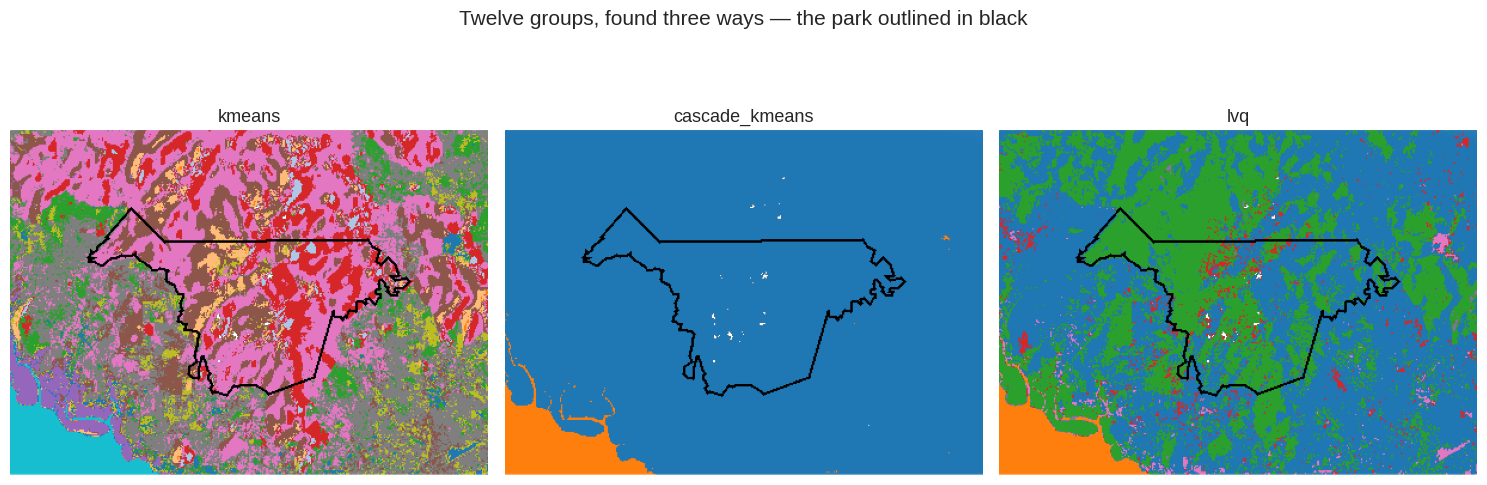

In [5]:
CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
                  '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78',
                  '#98df8a', '#ff9896', '#c5b0d5', '#c49c94']


def thumbnail(image, vis, dimensions=400):
    url = image.visualize(**vis).getThumbURL(
        {'region': area, 'dimensions': dimensions, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))


park_outline = ee.Image().byte().paint(park, 1, 2).visualize(palette=['000000'])
cluster_vis = {'min': 0, 'max': 15, 'palette': [c.lstrip('#') for c in CLUSTER_COLORS]}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, (algorithm, image) in zip(axes, clusters.items()):
    ax.imshow(thumbnail(image.visualize(**cluster_vis).blend(park_outline), {}))
    ax.set_title(algorithm)
    ax.axis('off')
fig.suptitle('Twelve groups, found three ways — the park outlined in black', y=1.0)
plt.tight_layout()

Three algorithms, one stack, and three completely different pictures.

**kmeans** covers the area in fine speckle. It used every cluster it was given and no group
dominates, which is what minimising within-cluster variance does to a landscape that varies
continuously: it cuts the continuum into equal-sized pieces wherever it can.

**cascade_kmeans** returns a single blue field with an orange wedge in the south-west corner.
That wedge is the sea. Given a ceiling of fifteen clusters it settled on two, and the split
it found is land against water.

**lvq** is the one that looks like a map. Green and blue form coherent patches that follow
the relief rather than scattering across it, with the green concentrated inside the park
boundary and on the hills to the north-east. That is the behaviour the intro hoped for: even
prototype sizes, so the structure inside a dominant cover type is not steamrollered by it.

## 6. How many groups did each one actually use?

Asking for twelve clusters does not mean twelve get used, and `cascade_kmeans` was given a
ceiling of fifteen precisely so it could answer the question itself.

One `frequencyHistogram` over a multi-band image returns one histogram per band, so the
three algorithms cost a single request between them rather than three. The scale is coarse
on purpose: this is a question about proportions, and a 300 m grid over 1700 km² still
counts nearly twenty thousand pixels.

In [6]:
SCALE = 300

stacked_clusters = ee.Image.cat(list(clusters.values())).rename(list(clusters))

histograms = stacked_clusters.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(), geometry=area, scale=SCALE,
    maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

shares = pd.DataFrame({
    algorithm: {int(k): v for k, v in histograms[algorithm].items()}
    for algorithm in clusters
}).sort_index()
shares = (shares / shares.sum()).fillna(0)

summary = pd.DataFrame({
    'clusters used': shares.gt(0).sum(),
    'largest cluster': shares.max().round(3),
    'smallest used': shares[shares > 0].min().round(4),
})
summary

,clusters used,largest cluster,smallest used
kmeans,12,0.332,0.0003
cascade_kmeans,2,0.959,0.0407
lvq,8,0.586,0.0001


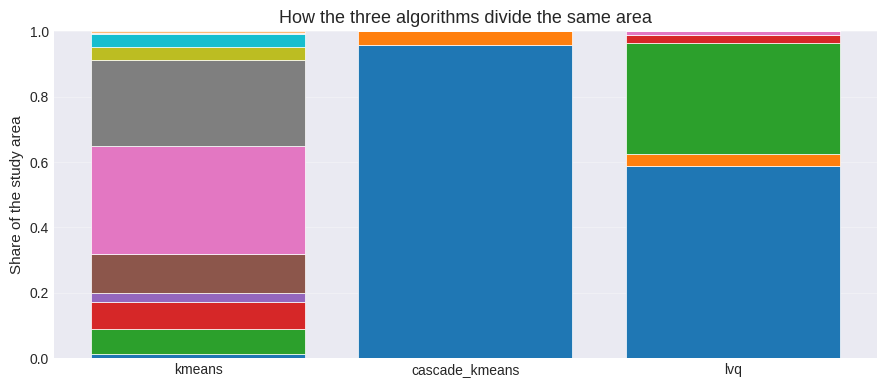

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(shares.columns))
for cluster in shares.index:
    values = shares.loc[cluster].values
    ax.bar(shares.columns, values, bottom=bottom,
           color=CLUSTER_COLORS[int(cluster) % len(CLUSTER_COLORS)],
           edgecolor='white', linewidth=0.5)
    bottom += values
ax.set_ylabel('Share of the study area')
ax.set_title('How the three algorithms divide the same area')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

The numbers behind the three pictures.

`kmeans` used all twelve clusters and its largest holds a third of the area. `lvq` used eight
of its twelve, with the largest at 59%. `cascade_kmeans`, allowed up to fifteen, used **two**,
and one of them covers 96% of the study area.

That last result is not a failure, and it is worth sitting with. The cascade keeps the number
of clusters that maximises the Calinski-Harabasz criterion, which rewards groups that are
compact and *well separated from each other*. In this stack exactly one separation is
genuinely sharp — water against land — and everything on the land side is a continuum:
canopies that are gradually taller, wetter or rougher, with no gap between them. Asked "how
many well-separated groups are there?", the honest answer for these features is two.

So the cascade is answering a different question from the other two. `kmeans` and `lvq` are
told to produce twelve groups and do as they are told; the cascade is asked whether twelve
groups are *there*, and says no. Use it to find out whether your stack has real structure,
not to produce a map.

## 7. Inside the forest

The question this notebook exists for. Take only what the reference map calls natural
forest — closed tree cover that the global oil palm layer does not claim — and look at how
the clusterers divide *that*.

Nothing here samples points. A grouped reducer answers the same question over every pixel in
one request: `ee.Reducer.mean().repeat(n).group(groupField=n)` takes an image whose first
`n` bands are the values and whose last band is the group, and returns the mean of each value
band within each group.

The terrain deserves a note. The Copernicus DEM is a collection of tiles, and a mosaic of it
takes Earth Engine's default projection — WGS84 at one degree. `ee.Terrain.slope` works on
neighbouring pixels *in the image's projection*, so without `setDefaultProjection` the slope
would come out of a one-degree grid and be essentially zero everywhere. This is the same trap
ndvi2gif hit in its own SAR terrain correction before 1.6.0.

In [8]:
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
oil_palm = (ee.ImageCollection('BIOPAMA/GlobalOilPalm/v1')
            .select('classification').mosaic().lte(2))
forest = worldcover.eq(10).And(oil_palm.Not())

# The tiles' own projection, or ee.Terrain.slope would read a 1-degree grid
tiles = ee.ImageCollection('COPERNICUS/DEM/GLO30_2024_1').select('DEM')
dem = tiles.mosaic().setDefaultProjection(tiles.first().projection())
terrain = dem.rename('elevation').addBands(ee.Terrain.slope(dem).rename('slope'))

forest_hist = stacked_clusters.updateMask(forest).reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(), geometry=area, scale=SCALE,
    maxPixels=1e9, bestEffort=True, tileScale=4).getInfo()

forest_shares = pd.DataFrame({
    algorithm: {int(k): v for k, v in forest_hist[algorithm].items()}
    for algorithm in clusters
}).sort_index()
forest_shares = (forest_shares / forest_shares.sum()).fillna(0)

(forest_shares.sort_values('lvq', ascending=False)
 .style.background_gradient(cmap='Greens', vmin=0, vmax=0.6)
 .format('{:.1%}')
 .set_caption('Share of the natural forest falling in each cluster'))

,kmeans,cascade_kmeans,lvq
0,0.7%,100.0%,50.8%
2,3.3%,0.0%,46.5%
3,14.3%,0.0%,2.2%
6,51.2%,0.0%,0.4%
4,0.1%,0.0%,0.0%
1,0.0%,0.0%,0.0%
5,15.9%,0.0%,0.0%
7,11.3%,0.0%,0.0%
8,2.0%,0.0%,0.0%
9,0.0%,0.0%,0.0%


In [9]:
VALUES = ['elevation', 'slope', 'S2_ndvi_mean', 'S2_ndmi_mean', 'S1_vv_mean', 'S1_vh_mean']
MIN_SHARE = 0.05


def forest_profile(algorithm):
    """Mean terrain and backscatter of every cluster holding part of the forest."""
    grouped = (terrain.addBands(stack.select(VALUES[2:]))
               .addBands(clusters[algorithm].rename('cluster'))
               .updateMask(forest)
               .reduceRegion(
                   reducer=ee.Reducer.mean().repeat(len(VALUES)).group(
                       groupField=len(VALUES), groupName='cluster'),
                   geometry=area, scale=SCALE, maxPixels=1e9,
                   bestEffort=True, tileScale=4).getInfo())

    table = pd.DataFrame(
        [dict(zip(VALUES, g['mean']), cluster=int(g['cluster']))
         for g in grouped['groups']]
    ).set_index('cluster')
    table['share of forest'] = forest_shares[algorithm]
    return table[table['share of forest'] >= MIN_SHARE].sort_values('elevation')


profiles = {a: forest_profile(a) for a in ['kmeans', 'lvq']}

pd.concat(profiles, names=['algorithm']).style.format(
    {'elevation': '{:.0f} m', 'slope': '{:.1f}°', 'S2_ndvi_mean': '{:.3f}',
     'S2_ndmi_mean': '{:.3f}', 'S1_vv_mean': '{:.2f}', 'S1_vh_mean': '{:.2f}',
     'share of forest': '{:.1%}'}).set_caption(
    f'Clusters holding at least {MIN_SHARE:.0%} of the natural forest, ordered by elevation')

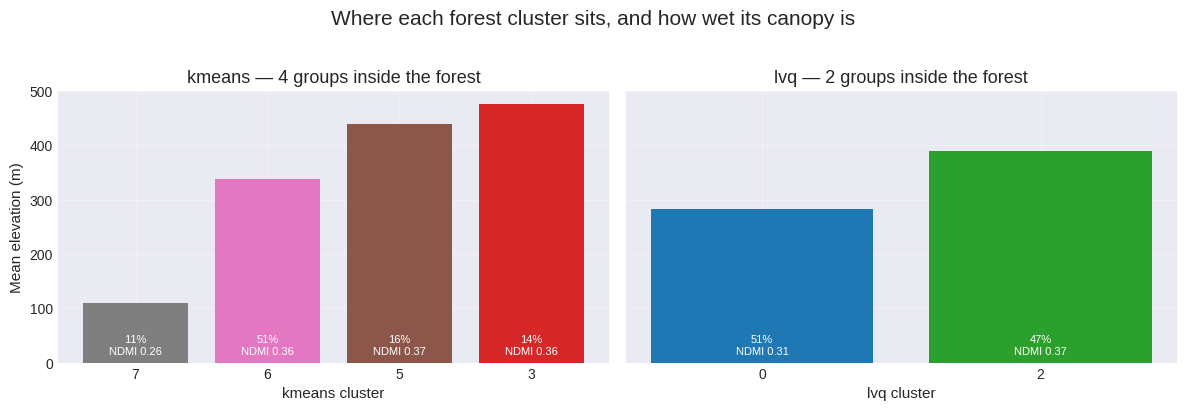

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, algorithm in zip(axes, profiles):
    table = profiles[algorithm]
    colors = [CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)] for c in table.index]
    ax.bar([str(int(c)) for c in table.index], table['elevation'], color=colors)
    for x, (share, ndmi) in enumerate(zip(table['share of forest'], table['S2_ndmi_mean'])):
        ax.text(x, 12, f'{share:.0%}\nNDMI {ndmi:.2f}', ha='center', va='bottom',
                fontsize=8, color='white')
    ax.set_xlabel(f'{algorithm} cluster')
    ax.set_title(f'{algorithm} — {len(table)} groups inside the forest')
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel('Mean elevation (m)')
fig.suptitle('Where each forest cluster sits, and how wet its canopy is', y=1.02)
plt.tight_layout()

This is the answer to the question the notebook opened with, and it is yes.

**kmeans splits the natural forest four ways, and the four sort themselves by elevation**:
109 m, 339 m, 439 m and 477 m, with mean slope climbing alongside from 3.7° to 11.0°. The
lowest group is also the driest canopy by some margin — NDMI 0.26 against 0.36–0.37 for the
three above it — and the least green, NDVI 0.789 against about 0.835. Nobody told the
clusterer that elevation exists: the DEM is not in the feature stack. It recovered the
gradient from optical and radar imagery alone.

**lvq splits it in two**, at 283 m and 389 m, and the two halves are almost equal in size
(50.8% and 46.5%). Same direction, coarser resolution: higher is greener and wetter.

The detail worth noticing is in the kmeans pair at the top. Clusters 5 and 3 sit at
practically the same height (439 m and 477 m) on practically the same slope (10.4° and
11.0°), and their optical signatures are nearly identical — yet their backscatter is not
close at all: VV −7.68 against −4.44, VH −14.17 against −11.25. Three decibels is a large
difference in canopy roughness and structure. Two stands of forest the optical bands cannot
tell apart, and the radar can. That is the multi-sensor stack earning its place.

And the dissenting vote: `cascade_kmeans` put **100%** of the forest in one cluster. By its
criterion there is nothing inside the forest to separate at all.

## 8. Seeing it on the ground

The forest clusters alone, over the park, with everything else greyed out.

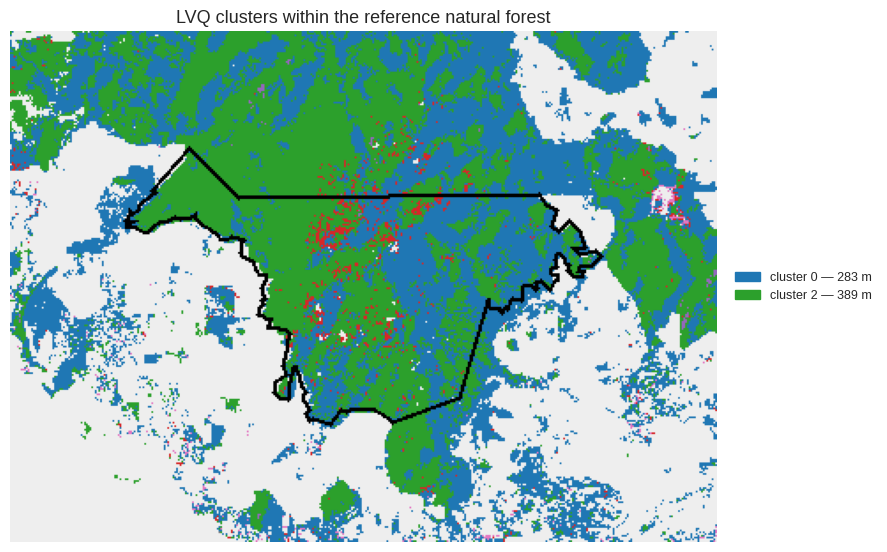

In [11]:
ALGORITHM = 'lvq'
lvq_forest = clusters[ALGORITHM].updateMask(forest)

fig, ax = plt.subplots(figsize=(9, 7))
base = ee.Image.constant(0).visualize(palette=['eeeeee'])
# 400 px, not 700: at 700 the render exceeds the user memory limit over this area
ax.imshow(thumbnail(base.blend(lvq_forest.visualize(**cluster_vis)).blend(park_outline),
                    {}, 400))
ax.set_title(f'{ALGORITHM.upper()} clusters within the reference natural forest')
ax.axis('off')
ax.legend(handles=[Patch(color=CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)],
                         label=f'cluster {int(c)} — '
                               f'{profiles[ALGORITHM].loc[c, "elevation"]:.0f} m')
                   for c in profiles[ALGORITHM].index],
          loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout()

The split holds up spatially, which a split found in feature space does not have to.

The higher cluster (green, mean 389 m) fills the core of the park and the hills to the
north-east; the lower one (blue, 283 m) rings the periphery and runs out into the lowlands
beyond the boundary. These are contiguous patches following the relief, not salt-and-pepper
noise, and the park boundary itself is invisible to the clusterer — it never saw it, and the
pattern crosses it wherever the terrain does.

Two honest caveats. The boundary between the two groups is **gradual on the ground**: a
forest that changes composition continuously with altitude does not have a line on it, so
where exactly the clusterer draws one is partly arbitrary and would move with a different
seed or a different year range. And the red speckle inside the park is a third cluster that
holds too little of the forest to have made the 5% cut — most likely canopy gaps, ridgelines
and the river.

## What to take away

**The rainforest does split on its own, and it splits by height.** Four groups from kmeans,
two from lvq, ordered by elevation in both cases and separated by canopy moisture — with no
labels, no training data and no DEM among the features. That is consistent with the lowland
to hill dipterocarp gradient Tawau Hills is known for, although consistency is not proof:
nothing here shows that cluster 7 *is* lowland dipterocarp. It shows that something real
changes with altitude and that the imagery can see it. Putting names on the groups needs
somebody on the ground.

**The algorithm decides how many pieces you get.** Four, two or none, from the same stack on
the same day. `kmeans` cuts a continuum into equal parts, `lvq` keeps its groups evenly sized
and so preserves structure inside a dominant cover type, and `cascade_kmeans` refuses to
invent groups it cannot justify. Pick the one whose bias matches your question rather than
the one that gives the prettiest map.

**Radar separates what the optical bands cannot.** The two upland kmeans clusters are
indistinguishable in NDVI and NDMI and three decibels apart in backscatter. On a
single-sensor stack they would have been one group.

**Cost is dominated by the number of years, not the number of bands.** Six years of this
stack cannot be rendered at all; three years renders in about four minutes per map. Dropping
the statistics bands or the SAR preprocessing does not help, because what exhausts the memory
budget is the multi-year median per tile. If an unsupervised run will not finish, shorten the
period before you start pruning features.

### See also

- [Multi-sensor classification](07_multisensor_classification.ipynb) — the supervised run
  over the same area, with the labels this notebook deliberately withheld.